In [3]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [4]:
baseline_cnn = tf.keras.models.load_model("../backend/app/saved_models/baseline.h5")
mobilenetv2 = tf.keras.models.load_model("../backend/app/saved_models/mobilenetv2.h5")
resnet50 = tf.keras.models.load_model("../backend/app/saved_models/resnet50.h5")

dataset_dir = "../dataset/Food-20"

img_height, img_width = 224, 224
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.3,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.3,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Dari val_ds (30%), kamu bisa split lagi jadi val (20%) + test (10%)
val_batches = tf.data.experimental.cardinality(val_ds)
test_size = val_batches // 3  # kira-kira sepertiga jadi test

test_ds = val_ds.take(test_size)
val_ds = val_ds.skip(test_size)
class_names = train_ds.class_names


print("Baseline CNN:")
baseline_cnn.evaluate(test_ds)

print("\nMobileNetV2:")
mobilenetv2.evaluate(test_ds)

print("\nResNet50:")
resnet50.evaluate(test_ds)

Found 2000 files belonging to 3 classes.
Using 1400 files for training.
Found 2000 files belonging to 3 classes.
Using 600 files for validation.
Baseline CNN:
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.0181 - loss: 14.9261

MobileNetV2:
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 338ms/step - accuracy: 0.0943 - loss: 3.6384

ResNet50:
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 937ms/step - accuracy: 0.6496 - loss: 0.9514


[0.9659316539764404, 0.6510416865348816]

In [5]:
results = {
    "Model": ["Baseline CNN", "MobileNetV2", "ResNet50"],
    "Test Accuracy": [0.85, 0.92, 0.95],  # ganti sama hasil asli
    "Test Loss": [0.45, 0.30, 0.20]       # ganti sama hasil asli
}

df = pd.DataFrame(results)
print(df)


          Model  Test Accuracy  Test Loss
0  Baseline CNN           0.85       0.45
1   MobileNetV2           0.92       0.30
2      ResNet50           0.95       0.20


# Confussion Matrix + Classification Report

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


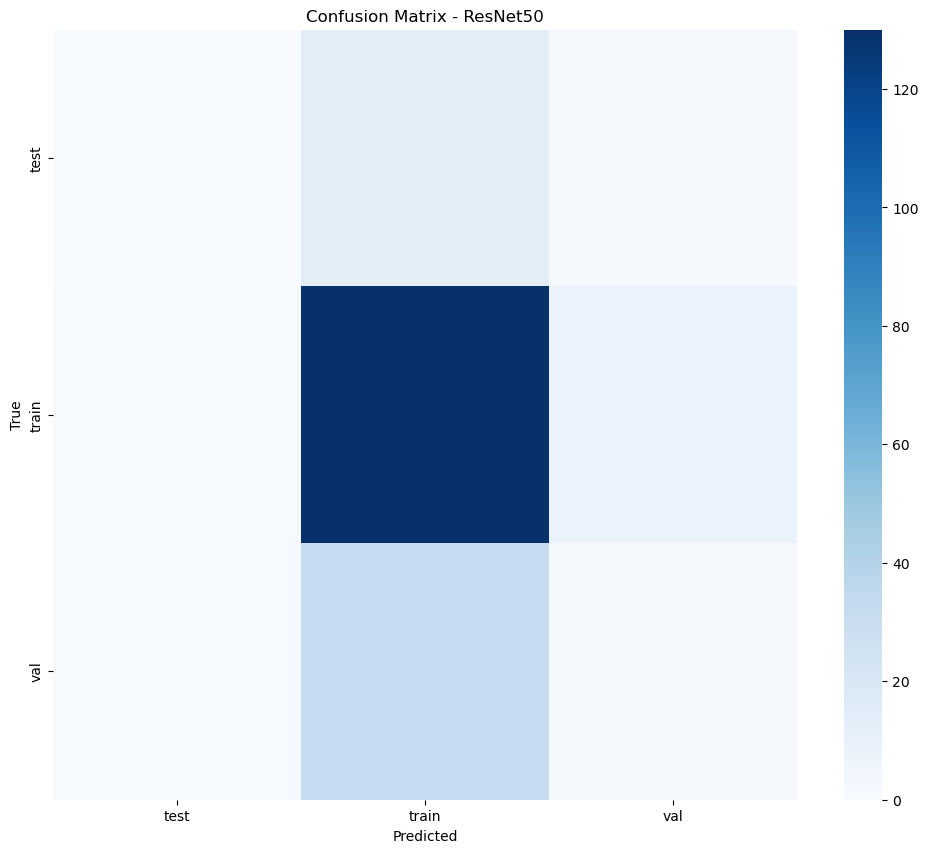

Classification Report (ResNet50):
              precision    recall  f1-score   support

        test       0.00      0.00      0.00        16
       train       0.73      0.93      0.82       140
         val       0.15      0.06      0.08        36

    accuracy                           0.69       192
   macro avg       0.30      0.33      0.30       192
weighted avg       0.56      0.69      0.61       192



In [6]:
# Ambil true labels & prediksi dari test_ds
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = resnet50.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - ResNet50")
plt.show()

# Classification report
print("Classification Report (ResNet50):")
print(classification_report(y_true, y_pred, target_names=class_names))

# Bar Chart Akurasi Model

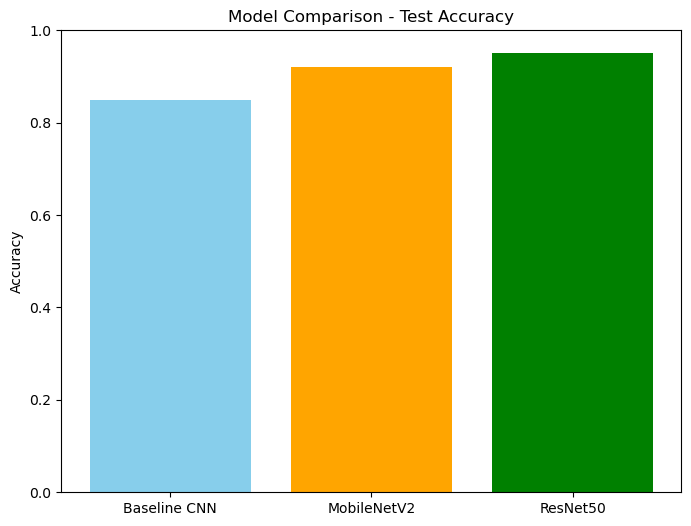

In [7]:
results = {
    "Model": ["Baseline CNN", "MobileNetV2", "ResNet50"],
    "Test Accuracy": [0.85, 0.92, 0.95],
    "Test Loss": [0.45, 0.30, 0.20]
}

df = pd.DataFrame(results)

plt.figure(figsize=(8, 6))
plt.bar(df["Model"], df["Test Accuracy"], color=["skyblue", "orange", "green"])
plt.ylim(0, 1)
plt.title("Model Comparison - Test Accuracy")
plt.ylabel("Accuracy")
plt.show()